<a href="https://colab.research.google.com/github/Parasshirishvaidya/aqi-regression-analysis/blob/main/notebooks/aqi_eda_box_cox_transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
url= r"https://raw.githubusercontent.com/Parasshirishvaidya/aqi-regression-analysis/refs/heads/main/dataset/city_day.csv"
df=pd.read_csv(url)
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,1/1/2015,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,1/1/2015,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,1/1/2015,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,1/1/2015,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,1/1/2015,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [10]:
num_cols=[ 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI',]

In [11]:
lambdas={}

In [12]:
for col in num_cols:
    data = df[col].dropna()
    shift = abs(data.min()) + 1 if (data <= 0).any() else 0
    transformed, lam = stats.boxcox(df[col].fillna(df[col].median()) + shift)
    df[f"{col}"] = transformed
    print(f"{col}: λ = {lam:.4f}")

PM2.5: λ = 0.7145
PM10: λ = 0.7095
NO: λ = 0.7204
NO2: λ = 0.7238
NOx: λ = 0.7207
NH3: λ = 0.7290
CO: λ = 0.7319
SO2: λ = 0.7120
O3: λ = 0.7209
Benzene: λ = 0.7454
Toluene: λ = 0.7401
Xylene: λ = 0.7284
AQI: λ = 0.7150


In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [15]:
df['City'].unique()

array(['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore'], dtype=object)

In [16]:
pollutants = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene', 'Xylene'
]

In [17]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,68.187298,75.825022,35.743184,29.207999,42.282122,12.858976,3.575256,20.678176,35.803881,6.465683,8.847828,3.555657,68.456756
std,31.668111,35.202670,16.814076,13.886398,19.834454,6.277834,1.844082,9.901786,16.797962,3.262322,4.373758,1.840541,31.736194
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.105341,48.164864,22.390689,18.097276,26.436140,7.824772,2.044354,12.649355,22.425826,3.810121,5.314211,2.053551,43.110338
50%,71.339916,79.485666,37.241656,30.667799,44.206502,13.502042,3.704422,21.649579,37.450411,6.716622,9.228742,3.666033,71.538185
75%,95.635191,106.289866,50.394726,41.248482,59.472548,18.302413,5.182387,29.293995,50.353613,9.309989,12.626656,5.169812,95.901370
max,117.433440,130.625148,61.941258,50.800389,73.024167,22.732461,6.535616,36.149192,62.081357,11.637131,15.806940,6.501347,117.748550


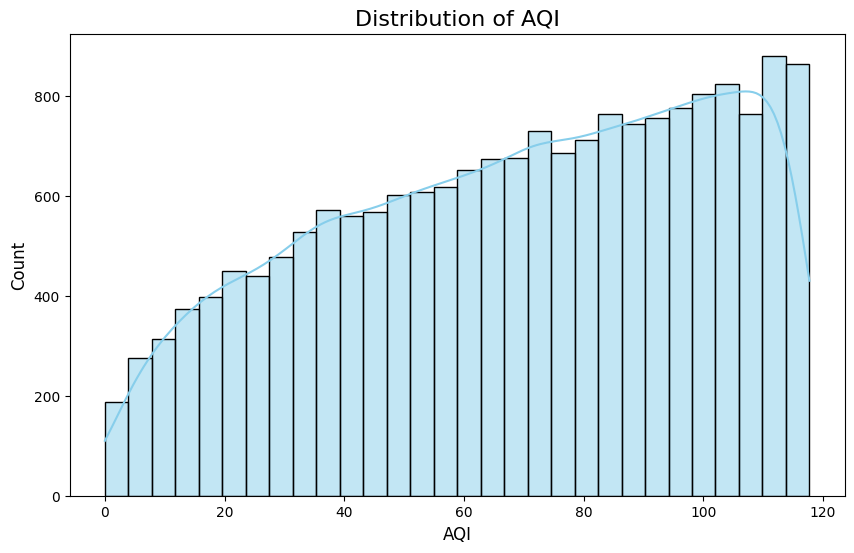

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['AQI'], bins=30, kde=True, color='skyblue')  # kde=True adds a smooth density curve
plt.title("Distribution of AQI", fontsize=16)
plt.xlabel("AQI", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [19]:
# Converting df to Yearly based data

# Convert 'Datetime' column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# This allows grouping data year-wise
df['Year'] = df['Datetime'].dt.year


# Group by BOTH Year and City
# This preserves city-wise structure instead of mixing all cities together
yearly_city_df = df.groupby(['Year', 'City']).mean(numeric_only=True).reset_index()

yearly_city_df

,Year,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,2015,Bangalore,68.212740,78.162419,33.754569,28.818878,42.937456,13.669101,3.487975,20.478455,35.246851,6.479346,9.229688,3.557855,67.112890
1,2015,Chennai,68.081674,77.912203,35.916201,29.081558,42.545255,12.968161,3.617917,20.968443,35.789941,6.365539,8.220442,3.586874,67.831940
2,2015,Delhi,68.593696,74.548412,35.511140,29.489808,41.377457,13.338772,3.543655,20.527820,35.213459,6.244247,9.337807,3.707459,67.715906
3,2015,Kolkata,67.748956,80.018922,36.705297,29.266169,43.217695,12.677223,3.642277,19.512587,35.519765,6.547808,8.690591,3.499591,67.675304
4,2015,Mumbai,68.684015,73.506953,34.884078,29.686943,42.595141,13.077536,3.584470,21.200329,35.923192,6.313565,9.315283,3.637407,68.348322
5,2016,Bangalore,66.769757,75.375835,35.417166,28.417946,42.531138,12.505369,3.746657,20.403733,35.706957,6.236366,8.907706,3.499834,70.017272
6,2016,Chennai,68.298588,76.921165,36.020106,29.315759,41.737608,13.301474,3.630944,20.539412,35.179733,6.462361,9.013701,3.479508,70.047977
7,2016,Delhi,64.184694,75.928215,34.598253,29.292463,41.527603,12.765527,3.574595,20.652580,35.858590,6.278462,8.875817,3.546264,69.344746
8,2016,Kolkata,68.748561,76.722083,36.282920,28.136293,41.009918,12.841322,3.626140,21.461443,36.245987,6.203838,8.787103,3.632852,66.100903
9,2016,Mumbai,66.845530,75.832615,35.871192,28.473752,43.671044,12.629769,3.573984,20.295091,35.728308,6.373800,8.307503,3.525988,65.378567


In [20]:
year_city_aqi = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()
result = year_city_aqi.loc[
    year_city_aqi.groupby('Year')['AQI'].idxmax()
]
result = result.sort_values('Year')
print(result)

    Year       City        AQI
4   2015     Mumbai  68.348322
6   2016    Chennai  70.047977
11  2017    Chennai  70.164118
19  2018     Mumbai  71.326420
23  2019    Kolkata  71.800457
25  2020  Bangalore  70.661652
32  2021      Delhi  70.030958
35  2022  Bangalore  69.826412
42  2023      Delhi  71.636582
48  2024    Kolkata  70.473154


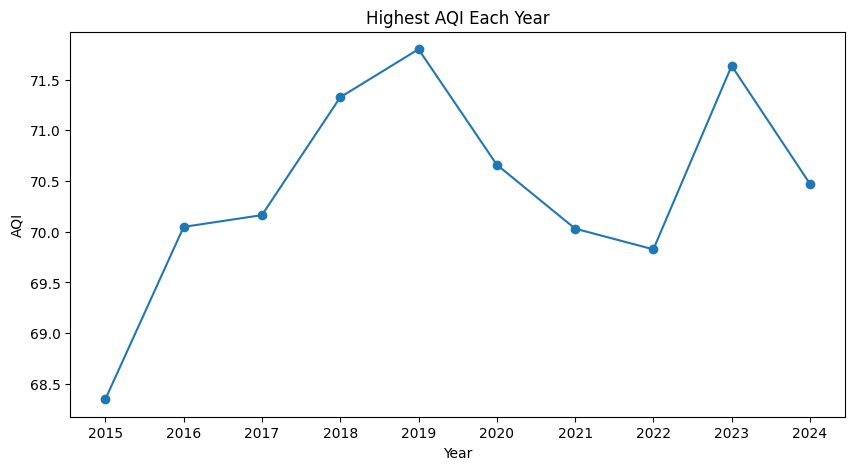

In [21]:
plt.figure(figsize=(10,5))
plt.plot(result['Year'], result['AQI'], marker='o')
plt.xticks(result['Year'])
plt.title("Highest AQI Each Year")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.show()

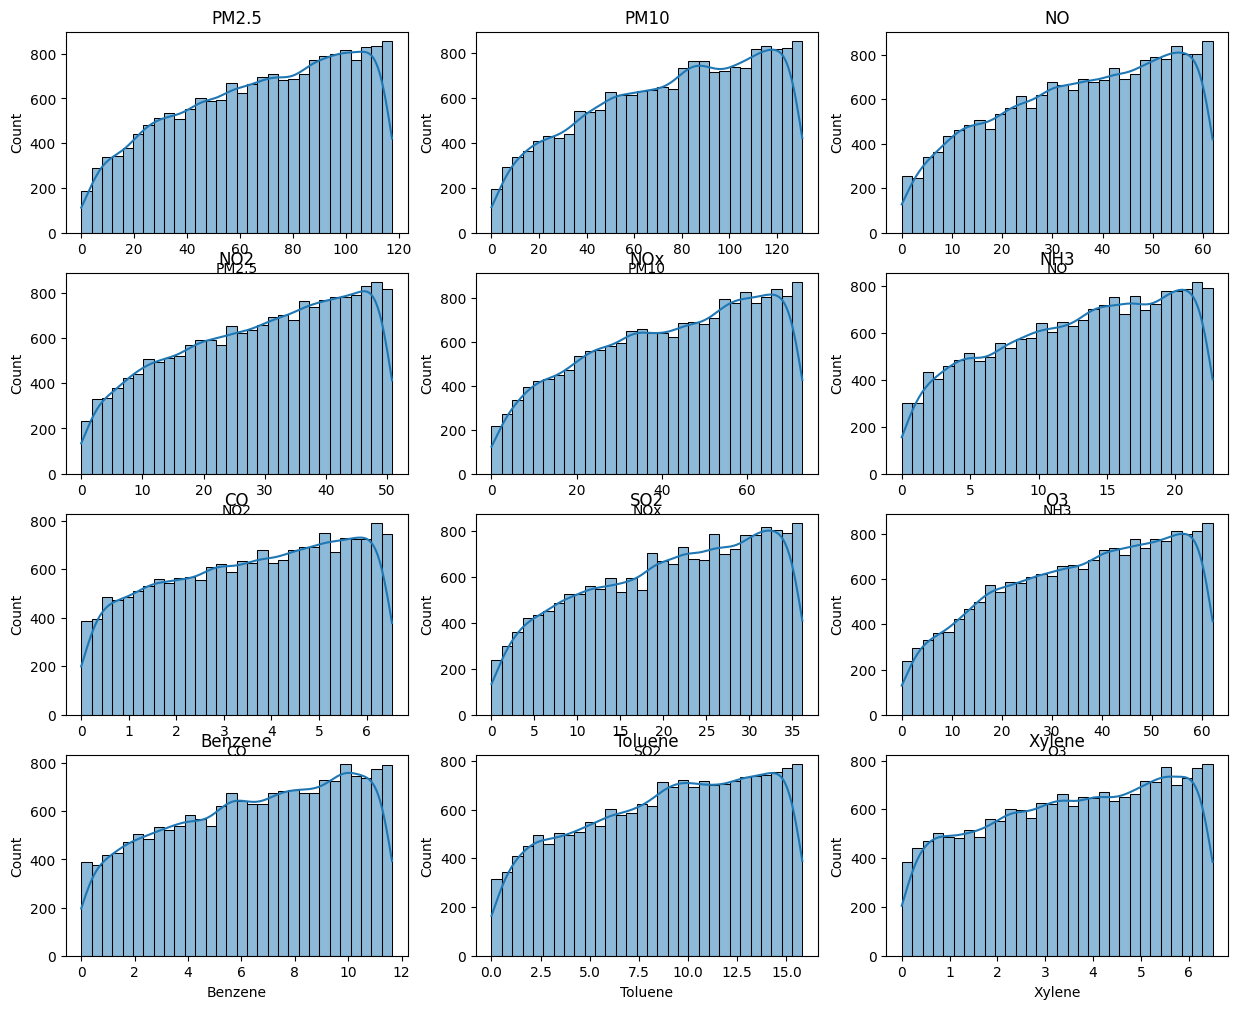

In [22]:
# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(pollutants):
    sns.histplot(df[col], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(col)


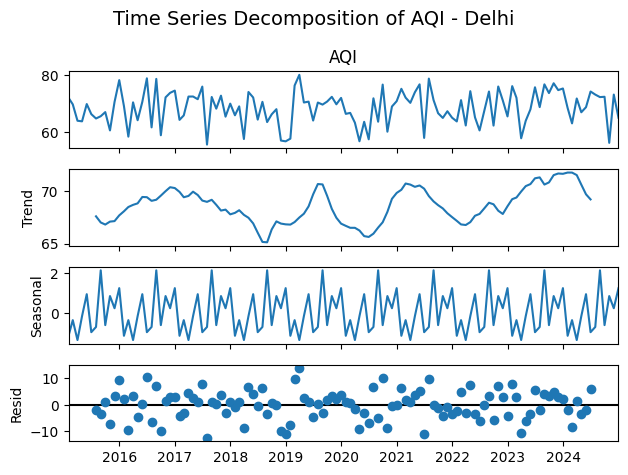

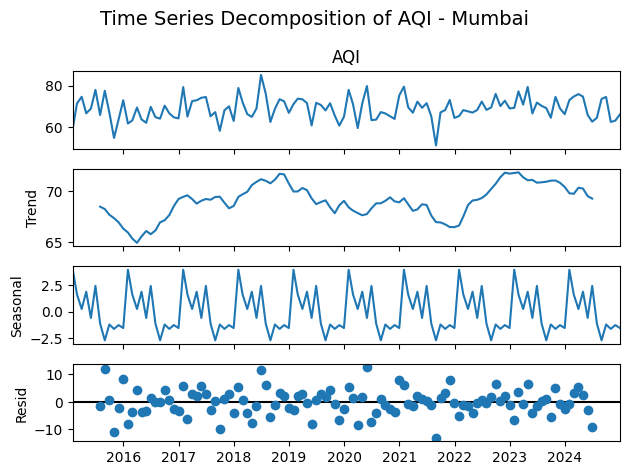

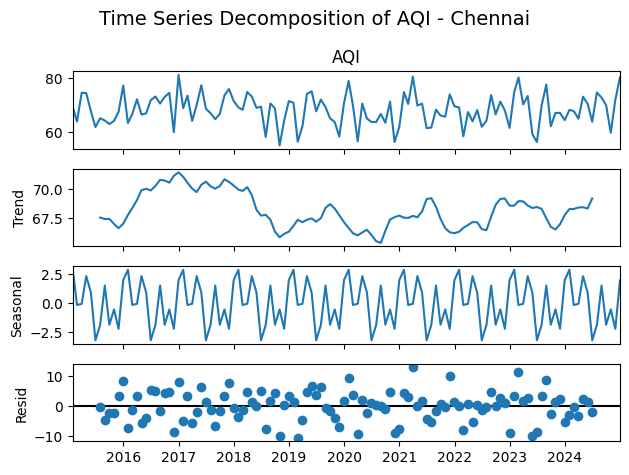

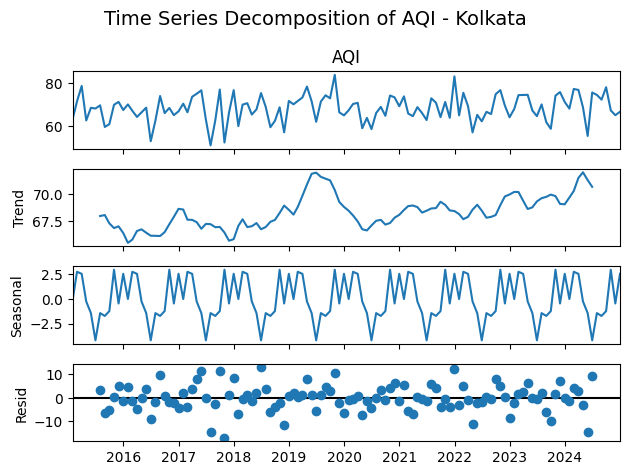

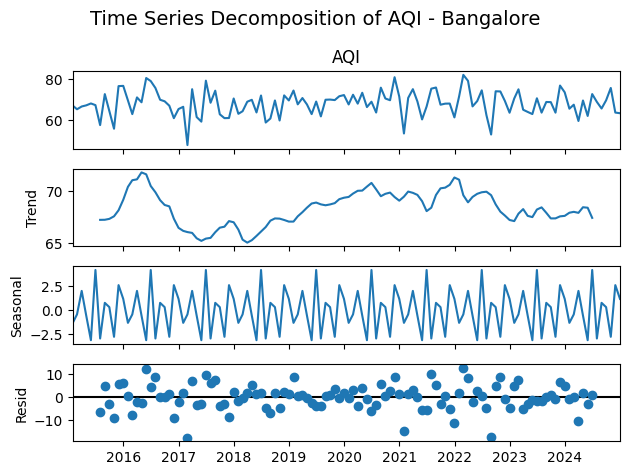

In [23]:
# ================================
# TIME SERIES DECOMPOSITION FOR ALL CITIES
# ================================

# --------------------------------
# STEP 1: Ensure 'Datetime' is a column (not index)
# --------------------------------
# This avoids errors if the cell is run multiple times
if df.index.name == 'Datetime':
    df = df.reset_index()

# --------------------------------
# STEP 2: Convert 'Datetime' to proper datetime format
# --------------------------------
# Required because time series methods need datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# --------------------------------
# STEP 3: Sort data by date
# --------------------------------
# Ensures correct chronological order for time series analysis
df = df.sort_values('Datetime')

# --------------------------------
# STEP 4: Set 'Datetime' as index
# --------------------------------
# Required for resampling and decomposition
df.set_index('Datetime', inplace=True)

# --------------------------------
# STEP 5: Loop through each city
# --------------------------------
# We do decomposition separately because each city has its own pattern
for city in df['City'].unique():

    # --------------------------------
    # STEP 5.1: Filter data for one city
    # --------------------------------
    # Decomposition requires a single continuous time series
    df_city = df[df['City'] == city]

    # --------------------------------
    # STEP 5.2: Select AQI series
    # --------------------------------
    # We are analyzing AQI behavior over time
    aqi_series = df_city['AQI']

    # --------------------------------
    # STEP 5.3: Resample to monthly data
    # --------------------------------
    # WHY: Daily data is too dense → cluttered plots
    # Monthly average reduces noise and improves visualization
    aqi_monthly = aqi_series.resample('ME').mean()

    # --------------------------------
    # STEP 5.4: Handle missing values (if any)
    # --------------------------------
    # Decomposition requires continuous data
    aqi_monthly = aqi_monthly.interpolate()

    # --------------------------------
    # STEP 5.5: Apply decomposition
    # --------------------------------
    # model='additive' → AQI = Trend + Seasonal + Noise
    # period=12 → yearly seasonality (since monthly data)
    result = seasonal_decompose(aqi_monthly, model='additive', period=12)

    # --------------------------------
    # STEP 5.6: Plot results
    # --------------------------------
    # Shows Observed, Trend, Seasonal, Residual
    result.plot()

    # Add title for clarity (which city this plot belongs to)
    plt.suptitle(f"Time Series Decomposition of AQI - {city}", fontsize=14)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display plot
    plt.show()

In [24]:
# Check if 'Datetime' is already the index and reset it if it is

if df.index.name == 'Datetime':
    df = df.reset_index()

df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a function to map months → seasons

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

# Apply the function to create 'Season' column

# Extract month from Datetime and map to season
df['Season'] = df['Datetime'].dt.month.map(get_season)



# Verify that seasons are correctly assigned
print(df[['Datetime', 'Season']])


#  Convert Season to categorical
# Helps in regression (statsmodels treats it properly)
df['Season'] = df['Season'].astype('category')

        Datetime  Season
0     2015-01-01  Winter
1     2015-01-01  Winter
2     2015-01-01  Winter
3     2015-01-01  Winter
4     2015-01-01  Winter
...          ...     ...
18260 2024-12-31  Winter
18261 2024-12-31  Winter
18262 2024-12-31  Winter
18263 2024-12-31  Winter
18264 2024-12-31  Winter

[18265 rows x 2 columns]


In [25]:
# Calculates spread/variability of AQI within each season in each city

print(df.groupby(['City','Season'])['AQI'].std())

City       Season      
Bangalore  Monsoon         32.623398
           Post-Monsoon    31.575678
           Summer          31.633104
           Winter          31.250156
Chennai    Monsoon         31.613758
           Post-Monsoon    33.037092
           Summer          31.790615
           Winter          31.184220
Delhi      Monsoon         31.599851
           Post-Monsoon    31.142402
           Summer          31.835378
           Winter          31.620661
Kolkata    Monsoon         31.401084
           Post-Monsoon    32.568989
           Summer          31.675050
           Winter          31.274692
Mumbai     Monsoon         31.670466
           Post-Monsoon    32.765971
           Summer          31.564231
           Winter          31.726498
Name: AQI, dtype: float64


/tmp/ipykernel_8331/1305574593.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['City','Season'])['AQI'].std())


In [26]:
# Calculates spread/variability of AQI within each season in each city in from 2015 to 2024

df.groupby(['Year','City','Season'])['AQI'].std()

/tmp/ipykernel_8331/2054187842.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].std()


Year  City       Season      
2015  Bangalore  Monsoon         31.441393
                 Post-Monsoon    32.603532
                 Summer          32.974572
                 Winter          33.010504
      Chennai    Monsoon         29.229444
                                   ...    
2024  Kolkata    Winter          29.822171
      Mumbai     Monsoon         30.123360
                 Post-Monsoon    34.444843
                 Summer          30.788422
                 Winter          32.105554
Name: AQI, Length: 200, dtype: float64

In [27]:
# Average AQI by Season AND City from 2015 to 2024
df.groupby(['Year','City','Season'])['AQI'].mean().unstack()

/tmp/ipykernel_8331/617288354.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].mean().unstack()


Season            Monsoon  Post-Monsoon     Summer     Winter
Year City                                                    
2015 Bangalore  64.927380     66.030706  67.321725  69.797360
     Chennai    64.202106     65.845310  69.701757  70.354293
     Delhi      65.817957     65.542102  66.033213  73.410370
     Kolkata    63.430718     70.611003  69.599787  67.415718
     Mumbai     70.151100     59.114801  72.013472  67.795442
2016 Bangalore  71.570395     64.074546  74.763678  66.067353
     Chennai    72.249680     67.406853  69.371648  70.499231
     Delhi      66.524286     72.925735  70.996470  67.581357
     Kolkata    67.594230     66.829961  63.131596  68.083285
     Mumbai     66.358805     65.678027  66.230278  63.044966
2017 Bangalore  68.608611     61.067849  68.723805  62.147298
     Chennai    66.199504     74.744429  70.084869  71.219829
     Delhi      65.410251     69.164394  73.053127  66.774837
     Kolkata    63.405060     59.194773  72.179769  71.383931
     Mumbai     63.599210     69.055104  73.508115  69.227483
2018 Bangalore  63.048374     65.848221  68.606565  65.730028
     Chennai    65.864406     59.644723  71.606465  69.697643
     Delhi      66.830838     62.710536  67.038042  63.796542
     Kolkata    63.659146     63.048552  69.818489  67.170971
     Mumbai     69.137029     72.927264  71.255687  72.575330
2019 Bangalore  67.231471     70.653583  67.582928  71.520180
     Chennai    68.852229     61.126219  69.770686  66.343148
     Delhi      70.228044     71.069680  71.348925  68.438804
     Kolkata    72.923812     75.295603  71.367705  68.869827
     Mumbai     70.054168     63.179930  69.324746  69.795549
2020 Bangalore  69.988293     75.126530  69.124881  70.409758
     Chennai    64.704070     63.968877  63.969968  70.178886
     Delhi      70.643161     64.553083  60.453529  68.039465
     Kolkata    66.642398     73.845094  63.158728  68.966306
     Mumbai     65.787540     64.597926  68.528065  74.812310
2021 Bangalore  72.910564     68.047903  67.787581  61.642635
     Chennai    65.403975     69.785935  70.683311  71.643766
     Delhi      72.235100     66.165496  69.796325  70.715817
     Kolkata    69.413781     67.626569  65.593023  74.588536
     Mumbai     61.091068     70.596926  69.965319  71.199135
2022 Bangalore  63.075526     71.654189  72.378259  72.029321
     Chennai    68.195859     69.685401  65.444438  63.247703
     Delhi      68.071660     73.543120  65.625352  66.709852
     Kolkata    68.990114     73.227091  63.535185  67.989543
     Mumbai     71.193848     71.389722  68.759062  67.474556
2023 Bangalore  67.075507     70.108837  65.654942  72.913211
     Chennai    69.927372     67.142358  64.842303  72.927740
     Delhi      73.019218     75.873139  66.356277  74.509522
     Kolkata    63.641943     75.026457  70.276588  71.140422
     Mumbai     68.000882     71.806748  72.084722  70.689289
2024 Bangalore  68.031908     69.751296  65.900144  65.460409
     Chennai    72.504240     65.789600  68.102357  72.195642
     Delhi      72.575598     64.615278  70.417832  65.614952
     Kolkata    74.974069     66.230536  69.119749  70.581187
     Mumbai     70.826436     62.794784  69.777301  71.222760

In [28]:
# Average AQI in each City from 2015 to 2024

df.groupby(['Year','City'])['AQI'].mean().unstack()

City,Bangalore,Chennai,Delhi,Kolkata,Mumbai
Year,,,,,
2015,67.112890,67.831940,67.715906,67.675304,68.348322
2016,70.017272,70.047977,69.344746,66.100903,65.378567
2017,65.793677,70.164118,68.928734,67.601732,69.210828
2018,66.035330,67.689397,65.463314,66.481770,71.326420
2019,68.978349,67.249347,70.302169,71.800457,68.597747
2020,70.661652,65.698062,65.584237,67.259426,68.746643
2021,67.607167,69.439481,70.030958,69.113988,68.138306
2022,69.826412,66.305050,67.832610,67.628204,69.495679
2023,68.547062,68.502081,71.636582,69.611108,70.664835


In [29]:
season_avg = df.groupby("Season")["AQI"].mean()

/tmp/ipykernel_8331/1887638743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_avg = df.groupby("Season")["AQI"].mean()


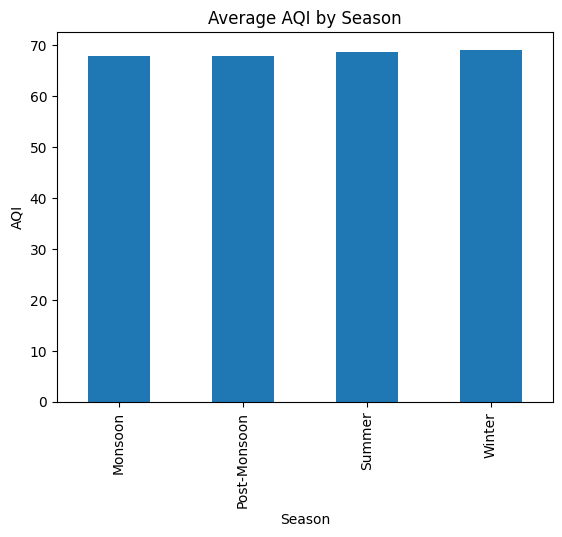

In [30]:
season_avg.plot(kind='bar', title='Average AQI by Season')
plt.ylabel('AQI')
plt.show()

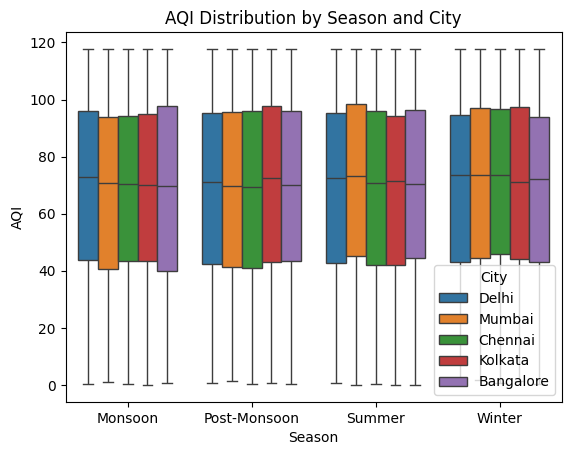

In [31]:
sns.boxplot(x='Season', y='AQI', hue='City', data=df)
plt.title('AQI Distribution by Season and City')
plt.show()

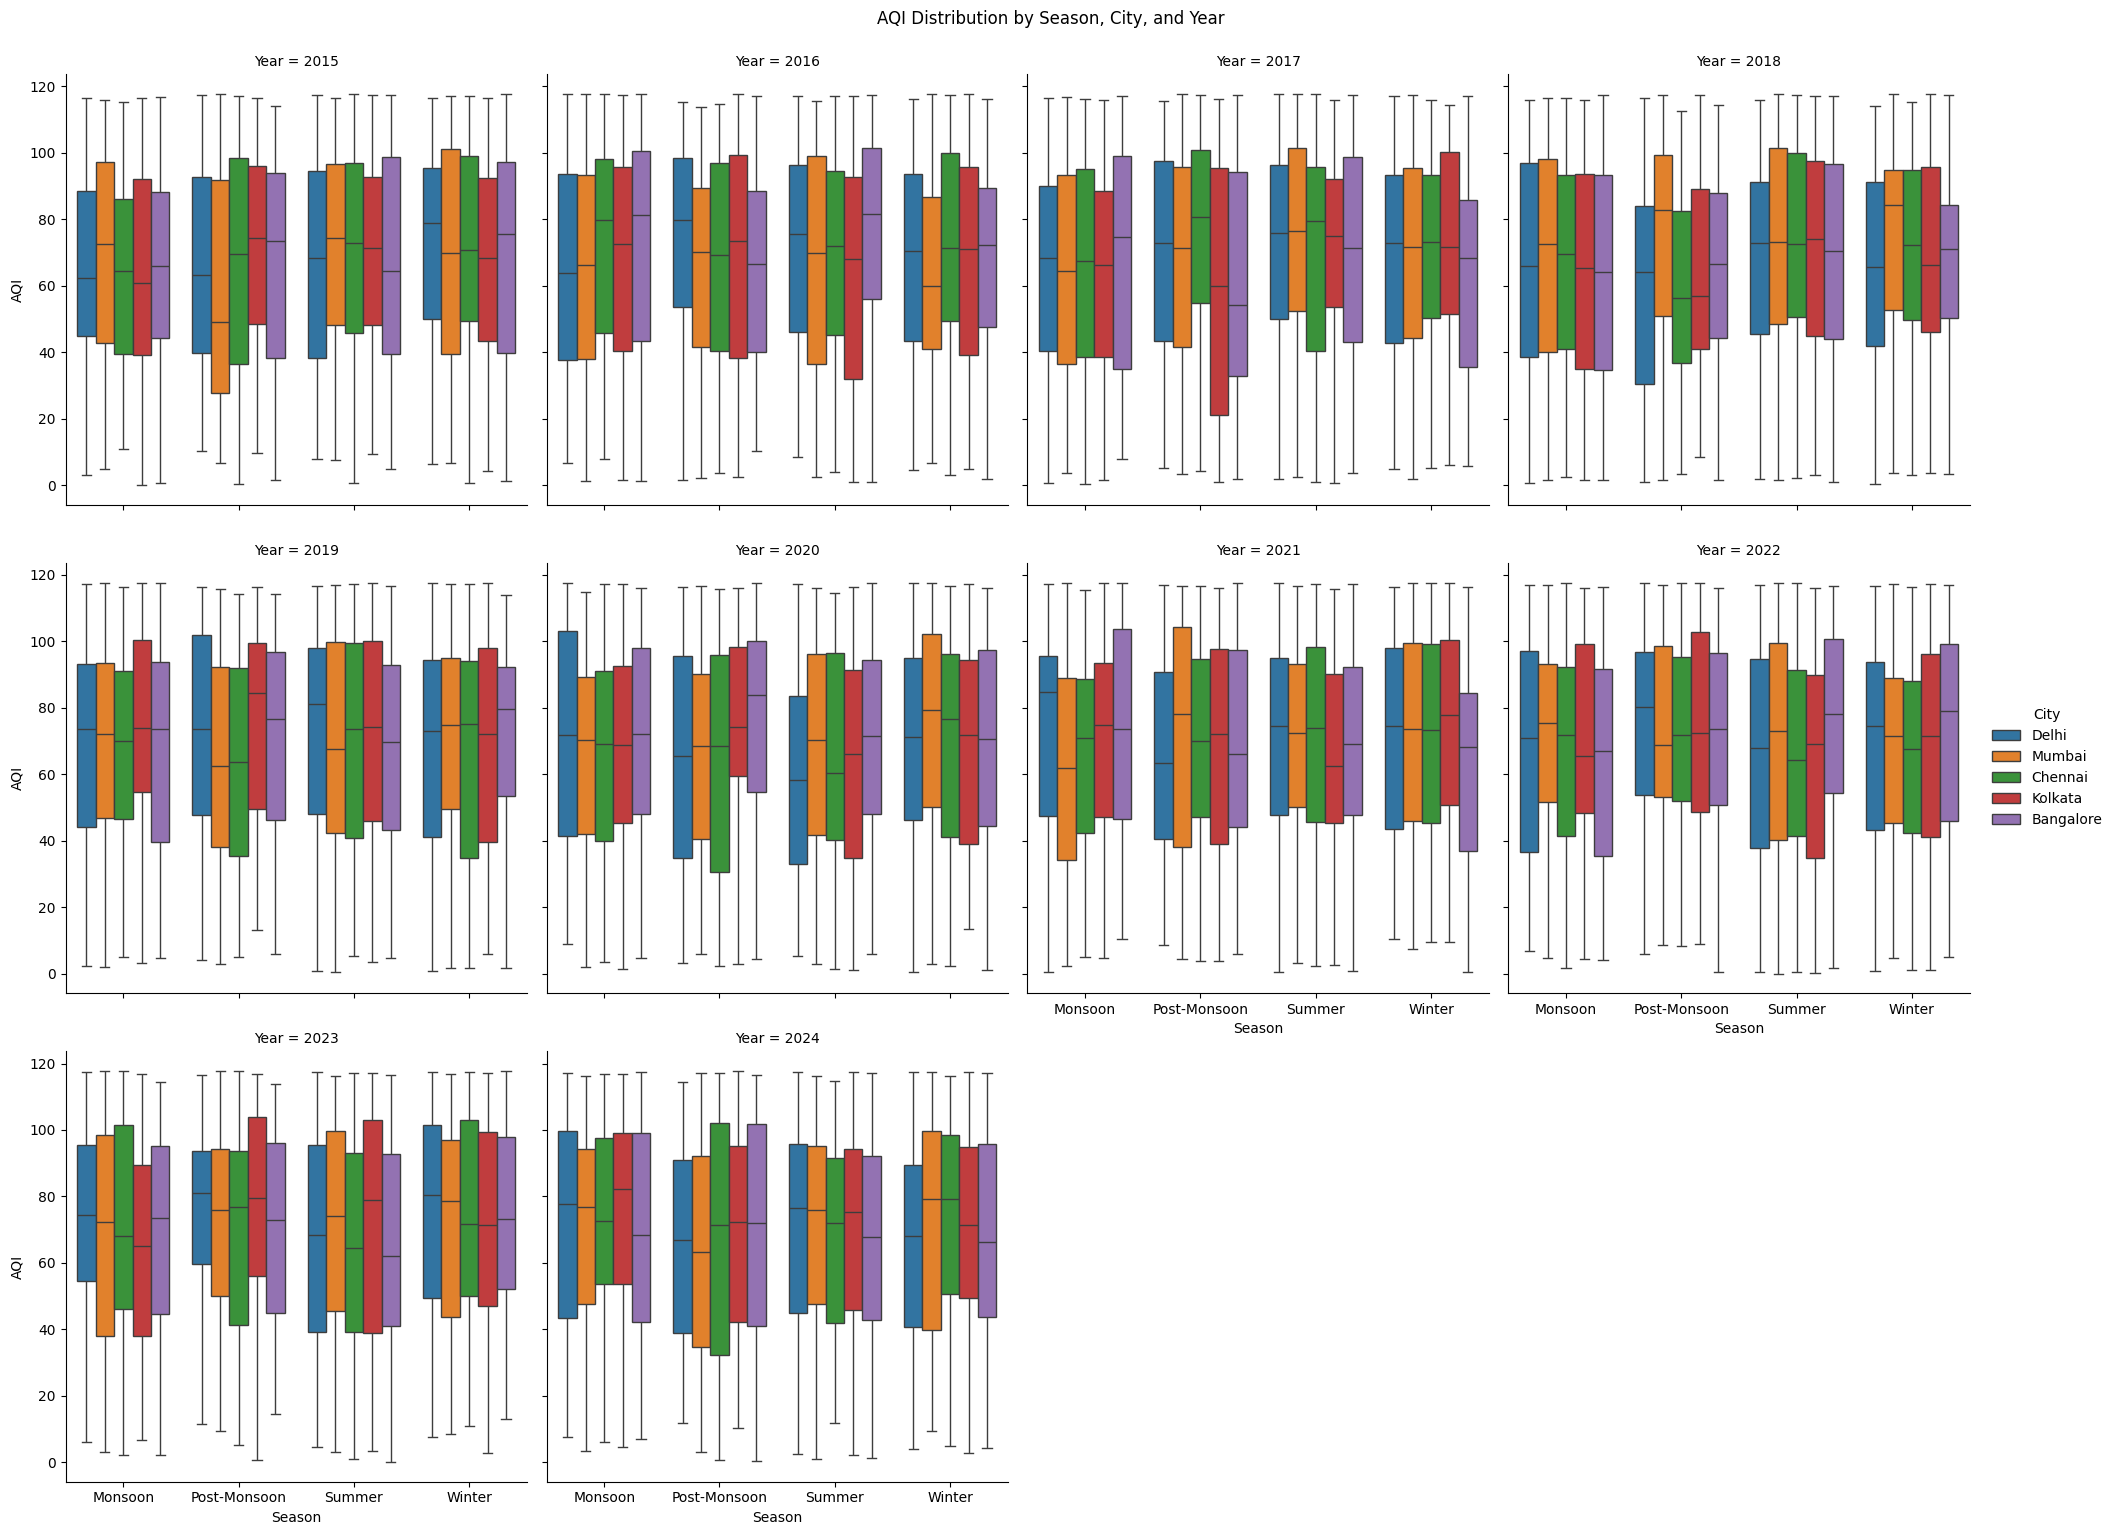

In [32]:
# Faceting splits the plot by Year, so you can compare seasonal patterns across years
g = sns.catplot(
    x='Season',
    y='AQI',
    hue='City',
    col='Year',            # <-- THIS adds Year dimension
    data=df,
    kind='box',
    col_wrap=4             # WHY: Keeps layout readable (4 plots per row)
)

# WHY: Adds a clear title for interpretation
g.fig.suptitle('AQI Distribution by Season, City, and Year', y=1.02)

plt.show()

In [33]:
from scipy.stats import shapiro, levene

alpha = 0.05  # significance level

for city in df['City'].unique():
    print("\n" + "="*60)
    print(f"ASSUMPTION CHECKS FOR CITY: {city}")
    print("="*60)

    city_df = df[df['City']==city]

    # -------------------------------
    # STEP 1: Normality per Season x Year group
    # -------------------------------
    print("\nNormality Check (Shapiro-Wilk) per Season x Year group:")

    normality_flag = True
    for season in city_df['Season'].unique():
        for year in city_df['Year'].unique():
            group = city_df[(city_df['Season']==season) & (city_df['Year']==year)]['AQI']
            if len(group) >= 3:  # Shapiro-Wilk requires at least 3 points
                stat, p = shapiro(group)
                result = "Normal" if p > alpha else "Not Normal"
                if p <= alpha:
                    normality_flag = False
                print(f"{season}-{year}: p={p:.4f} → {result}")

    # -------------------------------
    # STEP 2: Homogeneity of variances (Levene's test)
    # -------------------------------
    # Use AQI values grouped by Season
    groups = [city_df[city_df['Season']==s]['AQI'] for s in city_df['Season'].unique()]
    stat, p = levene(*groups)
    variance_result = "Equal variances" if p > alpha else "Unequal variances"
    print(f"\nHomogeneity of variances across Seasons: p={p:.4f} → {variance_result}")

    # -------------------------------
    # STEP 3: Recommendation
    # -------------------------------
    if not normality_flag or p <= alpha:
        print("\n=> ANOVA assumptions NOT satisfied. Consider using non-parametric alternatives (e.g., aligned-rank ANOVA).")
    else:
        print("\n=> ANOVA assumptions satisfied. You can proceed with Two-way ANOVA.")


ASSUMPTION CHECKS FOR CITY: Delhi

Normality Check (Shapiro-Wilk) per Season x Year group:
Winter-2015: p=0.0004 → Not Normal
Winter-2016: p=0.0025 → Not Normal
Winter-2017: p=0.0003 → Not Normal
Winter-2018: p=0.0037 → Not Normal
Winter-2019: p=0.0028 → Not Normal
Winter-2020: p=0.0033 → Not Normal
Winter-2021: p=0.0001 → Not Normal
Winter-2022: p=0.0004 → Not Normal
Winter-2023: p=0.0002 → Not Normal
Winter-2024: p=0.0067 → Not Normal
Summer-2015: p=0.0002 → Not Normal
Summer-2016: p=0.0002 → Not Normal
Summer-2017: p=0.0016 → Not Normal
Summer-2018: p=0.0006 → Not Normal
Summer-2019: p=0.0000 → Not Normal
Summer-2020: p=0.0005 → Not Normal
Summer-2021: p=0.0003 → Not Normal
Summer-2022: p=0.0002 → Not Normal
Summer-2023: p=0.0002 → Not Normal
Summer-2024: p=0.0000 → Not Normal
Monsoon-2015: p=0.0542 → Normal
Monsoon-2016: p=0.0010 → Not Normal
Monsoon-2017: p=0.0078 → Not Normal
Monsoon-2018: p=0.0012 → Not Normal
Monsoon-2019: p=0.0040 → Not Normal
Monsoon-2020: p=0.0000 → Not Nor

In [34]:
# ==========================================================
# NON-PARAMETRIC 2-WAY ANOVA (Scheirer-Ray-Hare)
# Tests: Season effect, Year effect, and Interaction effect
# Works when normality / equal variance is violated
# ==========================================================

from scipy.stats import rankdata, chi2

alpha = 0.05

# Function to perform Scheirer-Ray-Hare test
def srh_test(df, dv, factor1, factor2):
    """
    df      : pandas DataFrame
    dv      : dependent variable column (e.g., 'AQI')
    factor1 : first factor column (e.g., 'Season')
    factor2 : second factor column (e.g., 'Year')
    Returns : DataFrame with H-statistics and p-values
    """
    df = df.copy()
    df['rank'] = rankdata(df[dv])
    grand_mean = df['rank'].mean()

    # Sums of squares for factors
    n_total = len(df)
    ss_factor1 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor1)])
    ss_factor2 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor2)])
    # Interaction
    ss_inter = sum([len(sub) * (sub['rank'].mean() - grand_mean
                                - (df[df[factor1]==name1]['rank'].mean() - grand_mean)
                                - (df[df[factor2]==name2]['rank'].mean() - grand_mean))**2
                     for (name1, name2), sub in df.groupby([factor1, factor2])])

    # Total sum of squares
    ss_total = sum((df['rank'] - grand_mean)**2)

    # Residuals / error
    ss_error = ss_total - ss_factor1 - ss_factor2 - ss_inter

    # Degrees of freedom
    df1 = df[factor1].nunique() - 1
    df2 = df[factor2].nunique() - 1
    df_int = (df[factor1].nunique() - 1) * (df[factor2].nunique() - 1)

    # H-statistics
    H_factor1 = (12 / (n_total*(n_total+1))) * ss_factor1
    H_factor2 = (12 / (n_total*(n_total+1))) * ss_factor2
    H_inter = (12 / (n_total*(n_total+1))) * ss_inter

    # p-values
    p_factor1 = 1 - chi2.cdf(H_factor1, df1)
    p_factor2 = 1 - chi2.cdf(H_factor2, df2)
    p_inter = 1 - chi2.cdf(H_inter, df_int)

    results = pd.DataFrame({
        'Effect': [factor1, factor2, f'{factor1}x{factor2}'],
        'H': [H_factor1, H_factor2, H_inter],
        'df': [df1, df2, df_int],
        'p-value': [p_factor1, p_factor2, p_inter],
        'Significant': ['Yes' if p < alpha else 'No' for p in [p_factor1, p_factor2, p_inter]]
    })
    return results

# ------------------------------
# Run SRH test city-wise
# ------------------------------
for city in df['City'].unique():
    print("\n" + "="*70)
    print(f"CITY: {city}")
    print("="*70)

    city_df = df[df['City'] == city].copy()
    srh_results = srh_test(city_df, dv='AQI', factor1='Season', factor2='Year')
    print(srh_results)


CITY: Delhi
        Effect          H  df   p-value Significant
0       Season   0.512975   3  0.916032          No
1         Year  12.572318   9  0.182932          No
2  SeasonxYear  31.102568  27  0.266948          No

CITY: Mumbai
        Effect          H  df   p-value Significant
0       Season   5.763671   3  0.123692          No
1         Year   8.502040   9  0.484448          No
2  SeasonxYear  24.540912  27  0.600173          No

CITY: Chennai
        Effect          H  df   p-value Significant
0       Season   3.643113   3  0.302670          No
1         Year   7.686139   9  0.566059          No
2  SeasonxYear  24.453995  27  0.605032          No

CITY: Kolkata
        Effect          H  df   p-value Significant
0       Season   2.979049   3  0.394867          No
1         Year  10.214200   9  0.333425          No
2  SeasonxYear  33.618740  27  0.177412          No

CITY: Bangalore


/tmp/ipykernel_8331/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_8331/3464795143.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name1, name2), sub in df.groupby([factor1, factor2])])
/tmp/ipykernel_8331/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_8331/3464795143.py:

        Effect          H  df   p-value Significant
0       Season   0.781253   3  0.853946          No
1         Year   9.388841   9  0.402182          No
2  SeasonxYear  32.345853  27  0.219517          No


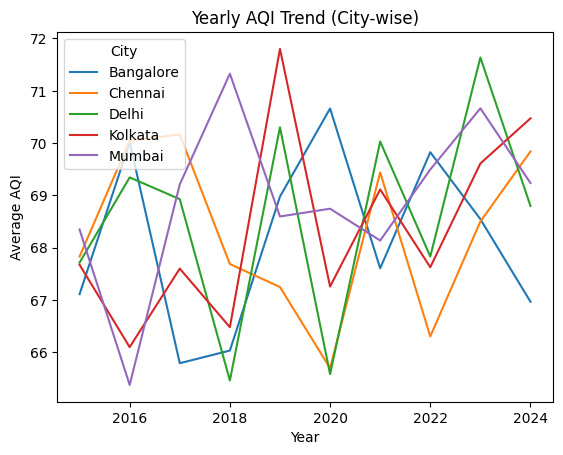

In [35]:
# Group by BOTH Year and City
yearly_city = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

sns.lineplot(data=yearly_city, x='Year', y='AQI', hue='City')

plt.title('Yearly AQI Trend (City-wise)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.show()

In [36]:
# Defining Covid Period

def covid_phase(date):
    if date < pd.Timestamp('2020-03-25'):
        return 'Pre-COVID'
    elif date <= pd.Timestamp('2020-05-31'):
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

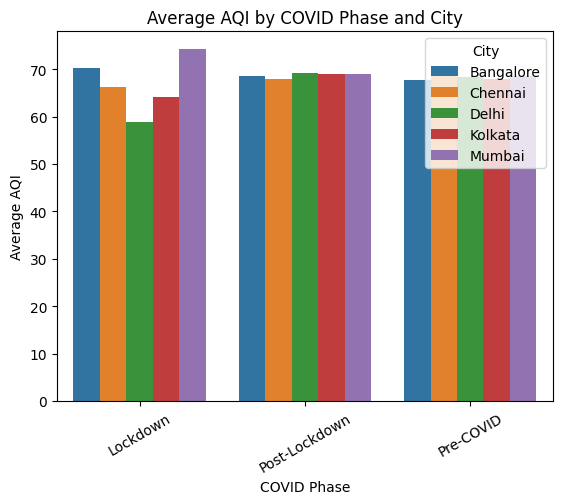

In [37]:

# Creating dataframe for Covid Period
df['COVID_Phase'] = df['Datetime'].apply(covid_phase)
df.groupby('COVID_Phase')['AQI'].mean()

#  Group by BOTH COVID_Phase and City
covid_city = df.groupby(['COVID_Phase', 'City'])['AQI'].mean().reset_index()


sns.barplot(data=covid_city, x='COVID_Phase', y='AQI', hue='City')
plt.title('Average AQI by COVID Phase and City')
plt.xlabel('COVID Phase')
plt.ylabel('Average AQI')
plt.xticks(rotation=30)

plt.show()

In [38]:
df.groupby(['City','COVID_Phase'])['AQI'].mean().unstack()

COVID_Phase,Lockdown,Post-Lockdown,Pre-COVID
City,,,
Bangalore,70.199595,68.654909,67.645154
Chennai,66.282591,67.941467,68.642377
Delhi,58.878036,69.259009,68.297976
Kolkata,64.093045,69.046921,67.936765
Mumbai,74.281934,69.013462,68.634661


<Axes: xlabel='Datetime', ylabel='AQI_Smooth'>

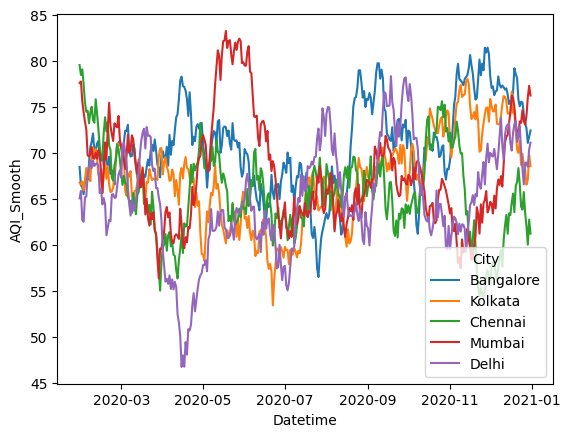

In [39]:
# Taking moving average to visualize the trend

# Defining dataframe for the lockdown period
df2020 = df.loc[(df['Datetime'] >= '2020-01-01') & (df['Datetime'] <= '2020-12-31')].copy()

# Apply 30-day moving average
df2020['AQI_Smooth'] = df2020.groupby('City')['AQI'].transform(lambda x: x.rolling(30).mean())

sns.lineplot(x='Datetime', y='AQI_Smooth', hue='City', data=df2020)

<Axes: xlabel='COVID_Phase', ylabel='AQI'>

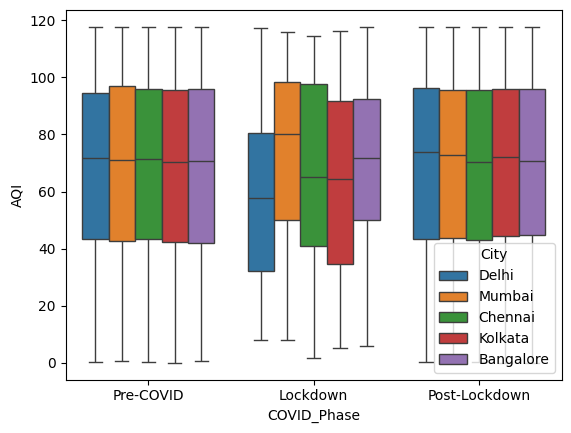

In [40]:
sns.boxplot(x='COVID_Phase', y='AQI', hue='City', data=df)

In [41]:
cities=['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']

In [42]:
# Make sure pandas shows all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

threshold = 0.3  # strong correlation threshold

for city in cities:
    city_df = df[df['City'] == city]

    # Compute correlation matrix
    corr_matrix = city_df[pollutants].corr()

    print("\n" + "="*70)
    print(f" CORRELATION MATRIX FOR CITY: {city.upper()}")
    print("="*70)
    print(corr_matrix.round(3))

    # Find strong correlations
    strong_corrs = []
    for i, col1 in enumerate(corr_matrix.columns):
        for j, col2 in enumerate(corr_matrix.columns):
            if j > i:  # upper triangle only to avoid duplicates
                corr_value = corr_matrix.loc[col1, col2]
                if abs(corr_value) > threshold:
                    strong_corrs.append((col1, col2, corr_value))

    if strong_corrs:
        print("\nStrong correlations (|r| > 0.3):")
        for col1, col2, val in strong_corrs:
            print(f"{col1} ↔ {col2} : {val:.3f}")
    else:
        print("\nNo strong correlations found.")


 CORRELATION MATRIX FOR CITY: DELHI
         PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2     O3  Benzene  Toluene  Xylene
PM2.5    1.000 -0.030 -0.028 -0.007 -0.013  0.019 -0.003 -0.027 -0.007   -0.024   -0.016  -0.020
PM10    -0.030  1.000  0.008  0.004  0.003 -0.039 -0.025  0.005 -0.004    0.003   -0.008   0.006
NO      -0.028  0.008  1.000 -0.017  0.007 -0.008  0.007  0.003 -0.006    0.022    0.008   0.030
NO2     -0.007  0.004 -0.017  1.000  0.004 -0.016  0.019 -0.004  0.009    0.005   -0.009  -0.006
NOx     -0.013  0.003  0.007  0.004  1.000  0.006  0.013 -0.018 -0.004   -0.029    0.016  -0.029
NH3      0.019 -0.039 -0.008 -0.016  0.006  1.000 -0.004  0.024 -0.003   -0.007    0.001   0.006
CO      -0.003 -0.025  0.007  0.019  0.013 -0.004  1.000 -0.005  0.017   -0.006   -0.000   0.020
SO2     -0.027  0.005  0.003 -0.004 -0.018  0.024 -0.005  1.000  0.009   -0.016    0.004   0.015
O3      -0.007 -0.004 -0.006  0.009 -0.004 -0.003  0.017  0.009  1.000   -0.008    0.012  

In [43]:
# Shapiro-Wilk test for Normality

from scipy.stats import shapiro

for pollutant in pollutants:
    print(f"\nNormality check for pollutant: {pollutant}")
    for city in df['City'].unique():
        stat, p = shapiro(df[df['City']==city][pollutant])
        result = "Normal" if p > 0.05 else "Not Normal"
        print(f"{city}: p-value={p:.4f} → {result}")


Normality check for pollutant: PM2.5
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: PM10
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO2
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NOx
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-

In [44]:
# ------------------------------------------
# POLLUTANT SIGNIFICANCE ACROSS CITIES
# Goal: For each pollutant, check if its levels differ significantly across the 5 cities.
# ------------------------------------------

from scipy import stats
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# Significance level
alpha = 0.05

# Loop over pollutants
for pollutant in pollutants:
    print("\n" + "="*70)
    print(f"POLLUTANT: {pollutant}")
    print("="*70)

    # Collect results per city
    sig_cities = []  # stores cities where pollutant is significant
    city_stats = []  # store F/H statistics and p-values

    # Loop over cities
    for city in df['City'].unique():
        city_data = df[df['City'] == city][pollutant]

        # Check normality
        p_normal = stats.shapiro(city_data)[1]

        # Check variance (not needed for Kruskal)
        # For demonstration, assume parametric if normal, else non-parametric
        if p_normal > alpha:
            # Parametric ANOVA (one-way across years or seasons if needed)
            # Here we assume just across years
            # You can modify grouping if needed
            # Since only one city data, we check distribution across Year
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                F_stat, p_val = stats.f_oneway(*year_groups)
            except:
                # fallback if group has only one value
                F_stat, p_val = float('nan'), 1.0
            city_stats.append((city, F_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)
        else:
            # Non-parametric: Kruskal-Wallis across years
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                H_stat, p_val = stats.kruskal(*year_groups)
            except:
                H_stat, p_val = float('nan'), 1.0
            city_stats.append((city, H_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)

    # Print city-wise F/H statistics and p-values
    for c, stat, p in city_stats:
        stat_name = "F-statistic" if p_normal > alpha else "H-statistic"
        print(f"{c:10s} → {stat_name}: {stat:.3f}, p-value: {p:.4f}")

    # Print overall summary
    if sig_cities:
        print(f"Result: {pollutant} is SIGNIFICANT for cities: {', '.join(sig_cities)}")
    else:
        print(f"Result: {pollutant} is NOT significant for any city")


POLLUTANT: PM2.5
Delhi      → H-statistic: 15.200, p-value: 0.0856
Mumbai     → H-statistic: 10.959, p-value: 0.2785
Chennai    → H-statistic: 6.632, p-value: 0.6754
Kolkata    → H-statistic: 4.436, p-value: 0.8805
Bangalore  → H-statistic: 2.932, p-value: 0.9669
Result: PM2.5 is NOT significant for any city

POLLUTANT: PM10
Delhi      → H-statistic: 6.810, p-value: 0.6569
Mumbai     → H-statistic: 8.284, p-value: 0.5058
Chennai    → H-statistic: 5.045, p-value: 0.8304
Kolkata    → H-statistic: 7.844, p-value: 0.5500
Bangalore  → H-statistic: 5.798, p-value: 0.7600
Result: PM10 is NOT significant for any city

POLLUTANT: NO
Delhi      → H-statistic: 13.124, p-value: 0.1571
Mumbai     → H-statistic: 4.889, p-value: 0.8439
Chennai    → H-statistic: 3.692, p-value: 0.9305
Kolkata    → H-statistic: 3.458, p-value: 0.9434
Bangalore  → H-statistic: 7.046, p-value: 0.6323
Result: NO is NOT significant for any city

POLLUTANT: NO2
Delhi      → H-statistic: 5.894, p-value: 0.7505
Mumbai     → 

In [45]:
import statsmodels.formula.api as smf

# Dictionary of significant pollutants per city from Kruskal-Wallis
sig_pollutants = {
    'Bangalore': ['NH3'],
    'Chennai': ['CO', 'Toluene'],
    'Mumbai': ['Toluene'],
    # Delhi, Kolkata → no significant pollutants
}

for city, pollutants_list in sig_pollutants.items():
    city_df = df[df['City'] == city]

    formula = "AQI ~ " + " + ".join(pollutants_list)
    lm = smf.ols(formula=formula, data=city_df).fit()

    print(f"\nCity: {city}")
    print(f"Model: AQI ~ {pollutants_list}")
    print(lm.summary())


City: Bangalore
Model: AQI ~ ['NH3']
                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5701
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.450
Time:                        17:33:16   Log-Likelihood:                -17817.
No. Observations:                3653   AIC:                         3.564e+04
Df Residuals:                    3651   BIC:                         3.565e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

In [46]:
import pandas as pd

# Make sure Datetime is a datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Define Lockdown Phase
def lockdown_phase(date):
    if date < pd.Timestamp('2020-03-25'):   # Before lockdown
        return 'Pre-Lockdown'
    elif date <= pd.Timestamp('2020-05-31'):  # Lockdown period
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

df['LockdownPhase'] = df['Datetime'].apply(lockdown_phase)

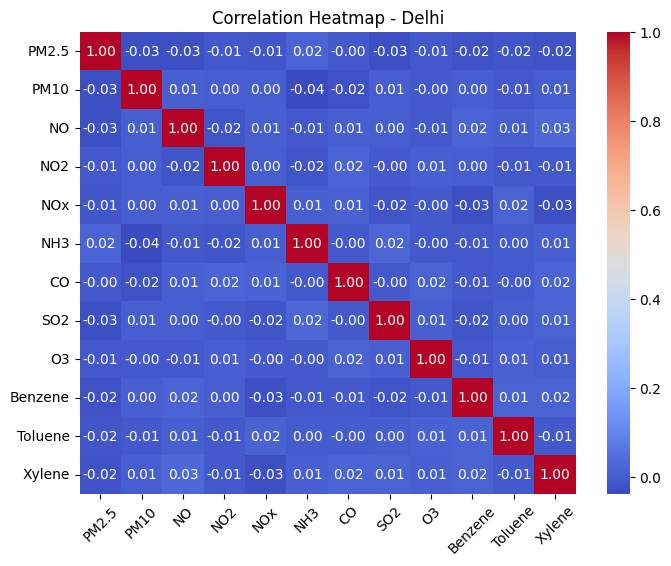

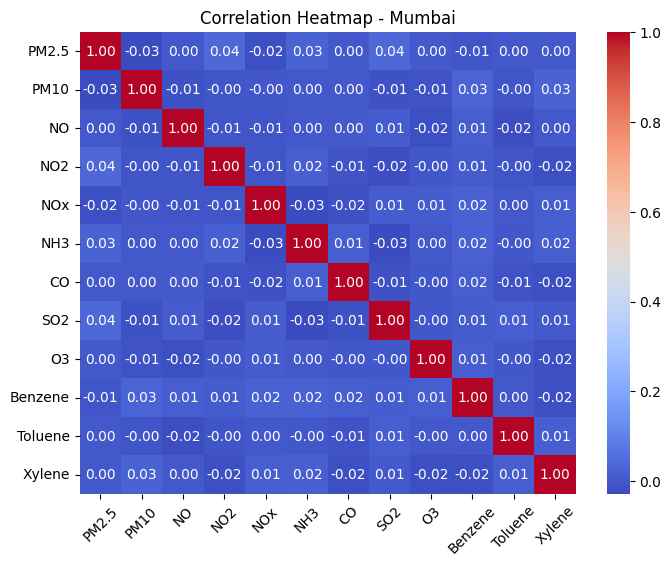

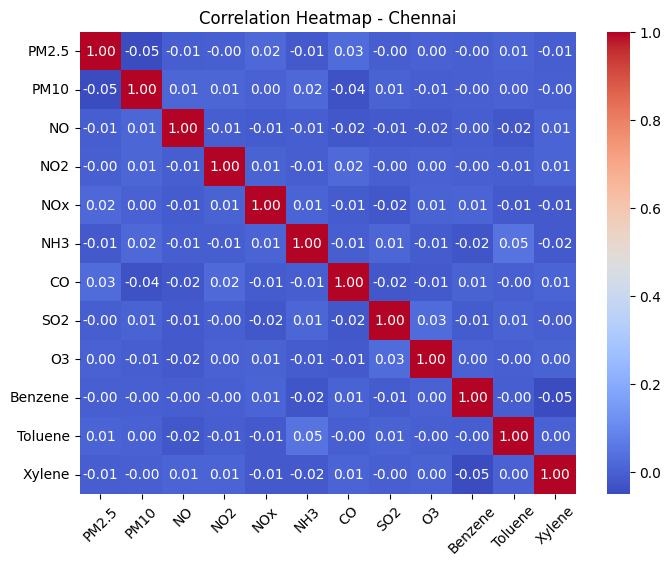

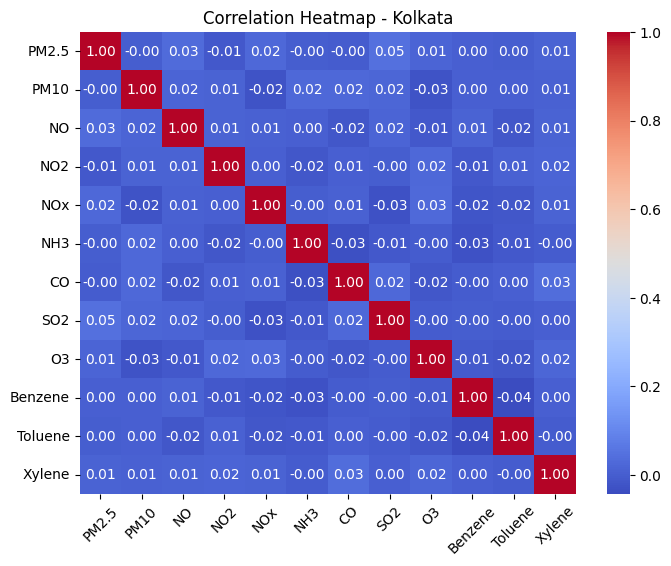

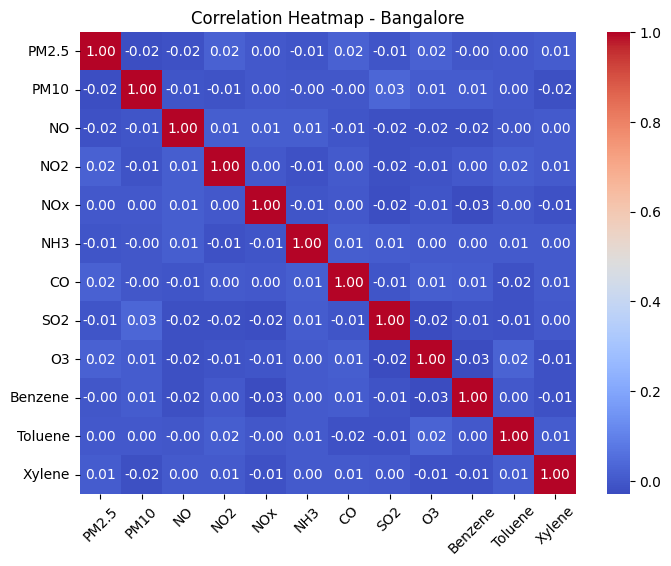

In [47]:
for city in df['City'].unique():
    plt.figure(figsize=(8,6))
    city_df = df[df['City'] == city]
    corr = city_df[pollutants].corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Heatmap - {city}')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

In [48]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Week'] = df['Datetime'].dt.to_period('W')

weekly_df = df.groupby(['City','Week']).mean(numeric_only=True).reset_index()

In [49]:
# Loop through each unique city in the weekly aggregated dataset
for city in weekly_df['City'].unique():

    # Print the city name for which correlation is being computed
    print(f"\nWeekly correlation for {city}:\n")

    # Subset the dataset for the current city only
    # This ensures we analyze within-city relationships (important to avoid mixing patterns)
    city_df = weekly_df[weekly_df['City'] == city]

    corr = city_df[pollutants].corr()

    print(corr)


Weekly correlation for Bangalore:

            PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene
PM2.5    1.000000 -0.018804 -0.091302 -0.018825  0.010123 -0.003732  0.079630 -0.060282 -0.007463  0.021735 -0.025123  0.030783
PM10    -0.018804  1.000000  0.000542 -0.063493  0.036351 -0.034061 -0.022406  0.007803 -0.000616  0.018824  0.019410  0.033027
NO      -0.091302  0.000542  1.000000  0.012950  0.068423  0.095201 -0.009544 -0.085981 -0.000035 -0.031395  0.028492  0.033664
NO2     -0.018825 -0.063493  0.012950  1.000000 -0.052548 -0.008182  0.058537  0.039728  0.017603  0.031910  0.003335  0.070220
NOx      0.010123  0.036351  0.068423 -0.052548  1.000000 -0.053631  0.029642  0.003799 -0.007742 -0.063947 -0.050795 -0.099882
NH3     -0.003732 -0.034061  0.095201 -0.008182 -0.053631  1.000000  0.048686 -0.005466  0.036014 -0.008834 -0.010096  0.005686
CO       0.079630 -0.022406 -0.009544  0.058537  0.029642  0.048686 

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
weekly_df[pollutants] = scaler.fit_transform(weekly_df[pollutants])

In [51]:
# Import required libraries
import pandas as pd

# Convert 'Datetime' column to proper datetime format
# WHY: Ensures we can extract time-based features like week, month, etc.
df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a 'Week' variable using pandas Period
# WHAT: Converts each date into its corresponding week
# WHY: Daily data is very noisy; weekly aggregation smooths fluctuations and reveals trends
df['Week'] = df['Datetime'].dt.to_period('W')


# Aggregate data at City + Week level
# WHAT: Taking mean of AQI and all pollutants for each city-week combination
# WHY: This reduces random day-to-day noise and gives a stable representation of pollution levels
weekly_df = df.groupby(['City', 'Week']).mean(numeric_only=True).reset_index()


# Check first few rows to confirm transformation
# WHY: Always verify data after transformation to avoid silent errors
print(weekly_df.head())

        City                   Week      PM2.5       PM10         NO        NO2        NOx        NH3        CO        SO2         O3   Benzene    Toluene    Xylene        AQI    Year
0  Bangalore  2014-12-29/2015-01-04  41.229854  57.319155  50.110794  30.896259  41.011046  20.295634  2.711165  21.893860  39.527113  7.714974   7.305310  5.626722  84.769039  2015.0
1  Bangalore  2015-01-05/2015-01-11  82.176550  91.756419  26.436136  24.692880  29.749309  13.100835  3.475447  23.752388  34.738061  6.807560  11.213452  4.510608  69.794531  2015.0
2  Bangalore  2015-01-12/2015-01-18  67.885205  73.521649  39.623662  31.964082  61.549085   8.693095  4.030383  17.967509  26.419489  5.156645   8.500994  3.355216  56.002807  2015.0
3  Bangalore  2015-01-19/2015-01-25  70.401504  51.906206  31.171186  33.426272  38.400009  10.337124  3.748195  18.797644  46.165708  5.550863  10.907882  3.599395  59.756868  2015.0
4  Bangalore  2015-01-26/2015-02-01  76.589751  58.618138  30.914583  34.037585 

In [52]:
# -------------------------------
# STEP 2A: Convert Week to timestamp
# -------------------------------

# Convert 'Week' (which is currently a period) back to a timestamp
# WHAT: Changes weekly period into an actual date (start of the week)
# WHY: Needed because regression models work better with numeric or datetime formats
weekly_df['Week_start'] = weekly_df['Week'].dt.start_time


# -------------------------------
# STEP 2B: Create a Time index
# -------------------------------

# Sort data by City and Week to maintain chronological order
# WHY: Time index must follow correct sequence for each city
weekly_df = weekly_df.sort_values(['City', 'Week_start'])

# Create a time variable (running index within each city)
# WHAT: Assigns 1, 2, 3, ... for each week per city
# WHY: Captures long-term trend (increase/decrease in AQI over time)
weekly_df['Time'] = weekly_df.groupby('City').cumcount() + 1


# -------------------------------
# STEP 2C: Create Lockdown variable
# -------------------------------

# Define lockdown period (India lockdown: 25 March 2020 – 31 May 2020)
# WHAT: Create a binary variable (0 = no lockdown, 1 = lockdown period)
# WHY: This is your main variable of interest (to measure lockdown effect)
weekly_df['Lockdown'] = ((weekly_df['Week_start'] >= '2020-03-25') &
                         (weekly_df['Week_start'] <= '2020-05-31')).astype(int)


# -------------------------------
# STEP 2D: (Optional but recommended) Post-lockdown variable
# -------------------------------

# WHAT: Indicator for post-lockdown period
# WHY: Helps capture recovery or rebound effect after lockdown ends
weekly_df['PostLockdown'] = (weekly_df['Week_start'] > '2020-05-31').astype(int)


# -------------------------------
# STEP 2E: Quick check
# -------------------------------

# Display a few rows to verify variables
# WHY: Ensures that Time and Lockdown variables are correctly created
weekly_df[['City', 'Week_start', 'Time', 'Lockdown', 'PostLockdown']]

,City,Week_start,Time,Lockdown,PostLockdown
0,Bangalore,2014-12-29,1,0,0
1,Bangalore,2015-01-05,2,0,0
2,Bangalore,2015-01-12,3,0,0
3,Bangalore,2015-01-19,4,0,0
4,Bangalore,2015-01-26,5,0,0
...,...,...,...,...,...
2610,Mumbai,2024-12-02,519,0,1
2611,Mumbai,2024-12-09,520,0,1
2612,Mumbai,2024-12-16,521,0,1
2613,Mumbai,2024-12-23,522,0,1


In [53]:
# Import required libraries for regression
import statsmodels.api as sm
import statsmodels.formula.api as smf


# -------------------------------
# STEP 3A: Fit baseline regression model
# -------------------------------

# WHAT: We are fitting a linear regression model using statsmodels
# WHY: This model helps us estimate the effect of Lockdown on AQI,
#      while controlling for time trend and city-specific differences

# Model specification:
# AQI ~ Lockdown + Time + C(City)
# - AQI = dependent variable
# - Lockdown = main variable of interest
# - Time = controls long-term trend
# - C(City) = treats City as categorical (fixed effects)

model_baseline = smf.ols(
    formula='AQI ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

print(model_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8576
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.525
Time:                        17:33:20   Log-Likelihood:                -10219.
No. Observations:                2615   AIC:                         2.045e+04
Df Residuals:                    2608   BIC:                         2.049e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             67.4241      0

In [54]:
# Import required function for quoting column names
from patsy import dmatrices, ModelDesc, Term, EvalFactor


# Convert pollutant names into safe format
# Q("PM2.5") instead of PM2.5
# Prevent syntax errors in regression formula
pollutants_quoted = [f'Q("{p}")' for p in pollutants]


# Build formula safely
# Combine all variables into regression formula
# This ensures model runs without syntax errors
formula = 'AQI ~ Lockdown + Time + C(City) + ' + ' + '.join(pollutants_quoted)


# Fit model
# Running corrected regression model
# Now statsmodels can correctly interpret all variables
model_full = smf.ols(formula=formula, data=weekly_df).fit()


print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.061
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.386
Time:                        17:33:20   Log-Likelihood:                -10212.
No. Observations:                2615   AIC:                         2.046e+04
Df Residuals:                    2596   BIC:                         2.057e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             64.7323      4

In [55]:
# Check correlation between AQI and PM2.5 (daily data)

print(df[['AQI', 'PM2.5']].corr())

            AQI     PM2.5
AQI    1.000000 -0.000326
PM2.5 -0.000326  1.000000


In [56]:
# Regress PM2.5 on lockdown, time, and city
# To measure how lockdown impacted pollution levels directly

model_pm25 = smf.ols(
    formula='Q("PM2.5") ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

# Print results
print(model_pm25.summary())

                            OLS Regression Results                            
Dep. Variable:             Q("PM2.5")   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6653
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.678
Time:                        17:33:20   Log-Likelihood:                -10226.
No. Observations:                2615   AIC:                         2.047e+04
Df Residuals:                    2608   BIC:                         2.051e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             67.6403      0

In [57]:
# Check summary statistics city-wise

print(df.groupby('City')[['AQI', 'PM2.5']].mean())

# Pollution should vary over time

print(df[['AQI', 'PM2.5']].describe())

# Look for obvious inconsistencies
print(df[['City', 'Datetime', 'AQI', 'PM2.5']])

                 AQI      PM2.5
City                           
Bangalore  68.155705  67.727338
Chennai    68.277064  68.542319
Delhi      68.563285  68.815207
Kolkata    68.374251  68.133315
Mumbai     68.913475  67.718313
                AQI         PM2.5
count  18265.000000  18265.000000
mean      68.456756     68.187298
std       31.736194     31.668111
min        0.000000      0.000000
25%       43.110338     43.105341
50%       71.538185     71.339916
75%       95.901370     95.635191
max      117.748550    117.433440
            City   Datetime         AQI       PM2.5
0          Delhi 2015-01-01   61.604090   49.834661
1         Mumbai 2015-01-01   25.316455   28.172341
2        Chennai 2015-01-01  115.444079   54.679382
3        Kolkata 2015-01-01   54.858794  113.560318
4      Bangalore 2015-01-01  115.991951   54.106142
...          ...        ...         ...         ...
18260    Chennai 2024-12-31   93.995201   57.959475
18261    Kolkata 2024-12-31   99.760666   89.453267
18

In [58]:
df.groupby(df['Datetime'].dt.year)[pollutants].corr()

PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene
Datetime                                                                                                                                
2015     PM2.5    1.000000 -0.060468 -0.044170  0.005942  0.031776  0.008384  0.028523 -0.019981  0.040125 -0.001406 -0.009923  0.008746
         PM10    -0.060468  1.000000 -0.036434  0.005060 -0.025794  0.045923 -0.019882  0.029381 -0.012801 -0.015690 -0.002268  0.014425
         NO      -0.044170 -0.036434  1.000000 -0.028804  0.019043 -0.034361 -0.000821  0.057718 -0.039487  0.031077 -0.020725  0.010281
         NO2      0.005942  0.005060 -0.028804  1.000000 -0.004009 -0.023998 -0.021108 -0.031662  0.015523  0.008904 -0.034716  0.023725
         NOx      0.031776 -0.025794  0.019043 -0.004009  1.000000 -0.036477 -0.010246 -0.006853 -0.045117 -0.029223 -0.017324 -0.035228
...                    ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...
2024     SO2      0.019019  0.026099 -0.010898 -0.015788 -0.050128  0.013315 -0.011798  1.000000  0.014130 -0.030939 -0.011155  0.023828
         O3       0.026782 -0.038707 -0.005242  0.015228  0.012246  0.001793  0.016870  0.014130  1.000000 -0.045262  0.014081 -0.026548
         Benzene -0.036285 -0.000922  0.006714 -0.009299 -0.007351 -0.018787 -0.003984 -0.030939 -0.045262  1.000000 -0.012590 -0.014623
         Toluene  0.018870 -0.008220  0.001086 -0.048674  0.024692 -0.000962 -0.008066 -0.011155  0.014081 -0.012590  1.000000 -0.004822
         Xylene   0.042557  0.010919 -0.000997  0.019921 -0.034871 -0.016268  0.025406  0.023828 -0.026548 -0.014623 -0.004822  1.000000

[120 rows x 12 columns]

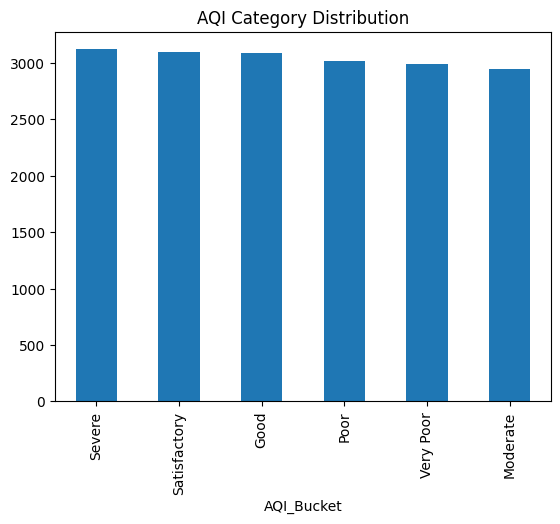

In [59]:
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.show()

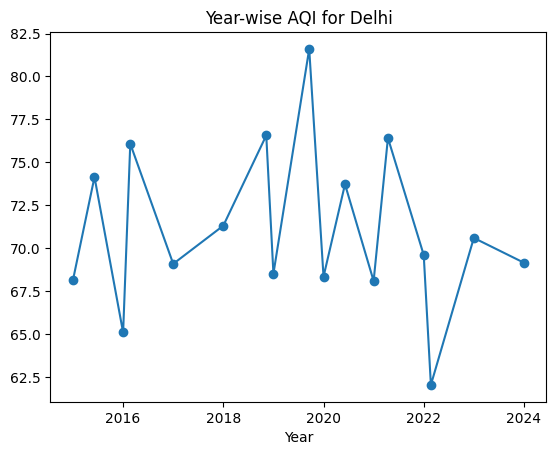

In [60]:
city_year_aqi = city_df.groupby('Year')['AQI'].mean()

city_year_aqi.plot(marker='o')
plt.title("Year-wise AQI for Delhi")
plt.show()

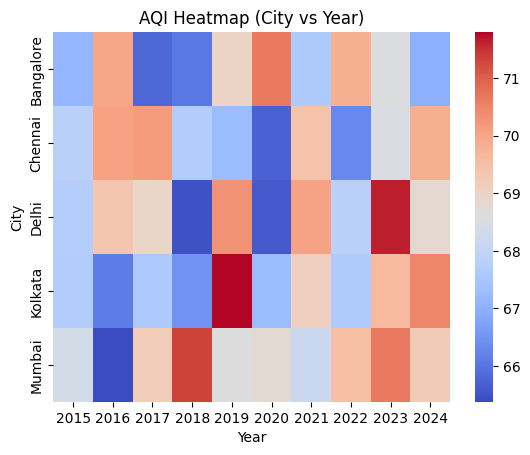

In [61]:
pivot = df.pivot_table(values='AQI', index='City', columns='Year', aggfunc='mean')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("AQI Heatmap (City vs Year)")
plt.show()

In [62]:
# -------------------------------
# Convert datetime properly
# -------------------------------
df['Date'] = pd.to_datetime(df['Datetime'])   # use your correct column name

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# -------------------------------
# CLEAN COLUMN NAMES
# -------------------------------
# Remove spaces and special characters
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace(r'[^\w]', '', regex=True)

# Print to verify pollutant names
print("Columns after cleaning:")
print(df.columns)

# -------------------------------
# MONTHLY AGGREGATION (KEEP ALL POLLUTANTS)
# -------------------------------
monthly_df = df.groupby(['City', 'Year', 'Month']).agg({
    'AQI': 'mean',
    'PM25': 'mean',     # adjust if your column is PM2_5
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean',
    'Benzene': 'mean',
    'Toluene': 'mean',
    'Xylene': 'mean'

}).reset_index()

# -------------------------------
# RENAME FOR CONSISTENCY (OPTIONAL BUT RECOMMENDED)
# -------------------------------
monthly_df = monthly_df.rename(columns={
    'PM25': 'PM2_5'
})

# -------------------------------
# CREATE TIME FEATURES
# -------------------------------
# Create proper datetime column
monthly_df['MonthStart'] = pd.to_datetime(monthly_df[['Year', 'Month']].assign(DAY=1))

# Sort properly
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])

# Time index (trend)
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical (for seasonality)
monthly_df['Month'] = monthly_df['Month'].astype('category')

# -------------------------------
# OPTIONAL 3-MONTH ROLLING AVERAGE
# -------------------------------
monthly_df['AQI_3month_avg'] = monthly_df.groupby('City')['AQI'] \
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# -------------------------------
# FINAL CHECK
# -------------------------------
print("\nFinal columns in monthly_df:")
print(monthly_df.columns)

# View full dataframe
monthly_df

Columns after cleaning:
Index(['Datetime', 'City', 'PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Season', 'COVID_Phase', 'LockdownPhase', 'Week', 'Date', 'Month'], dtype='object')

Final columns in monthly_df:
Index(['City', 'Year', 'Month', 'AQI', 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'MonthStart', 'TimeIndex', 'AQI_3month_avg'], dtype='object')


,City,Year,Month,AQI,PM2_5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,MonthStart,TimeIndex,AQI_3month_avg
0,Bangalore,2015,1,67.052750,70.131215,66.535067,34.443535,30.881543,41.399373,11.948378,3.682233,20.260466,36.033843,6.070665,9.824399,4.012765,2015-01-01,0,67.052750
1,Bangalore,2015,2,65.313821,73.470454,78.072063,34.626516,30.193883,40.062388,12.343462,3.179819,20.424827,32.200657,7.047754,9.569493,3.306619,2015-02-01,1,66.183286
2,Bangalore,2015,3,66.653836,60.215676,83.195896,34.072774,30.498381,42.016322,12.692927,3.615809,19.201980,38.024011,7.461227,8.353479,2.812291,2015-03-01,2,66.340136
3,Bangalore,2015,4,67.201381,67.210952,74.652243,36.471158,28.187655,45.929312,12.387286,3.883668,19.087302,32.934300,5.179469,11.159517,3.676220,2015-04-01,3,66.389680
4,Bangalore,2015,5,68.121384,69.341869,81.678852,32.746547,34.093002,43.241760,15.998641,3.060607,19.642698,36.896544,6.238767,8.677478,3.880272,2015-05-01,4,67.325534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Mumbai,2024,8,73.594519,63.744553,84.125519,32.189974,28.215962,43.973903,12.785431,3.702736,20.241608,39.090622,6.212016,6.870168,3.833750,2024-08-01,115,66.895119
596,Mumbai,2024,9,74.522879,64.317895,76.514784,35.275141,31.435417,41.095351,12.549454,3.514410,20.206508,34.318445,5.458052,9.524772,3.443810,2024-09-01,116,70.866182
597,Mumbai,2024,10,62.473483,71.576654,81.823061,38.454057,24.149689,41.207133,12.073268,3.270457,21.074910,36.822340,6.787694,8.827682,3.329844,2024-10-01,117,70.196960
598,Mumbai,2024,11,63.126795,60.617120,70.784912,32.738068,31.371200,44.012182,12.742501,2.930439,21.465947,34.580167,6.803079,8.766096,3.047326,2024-11-01,118,66.707719


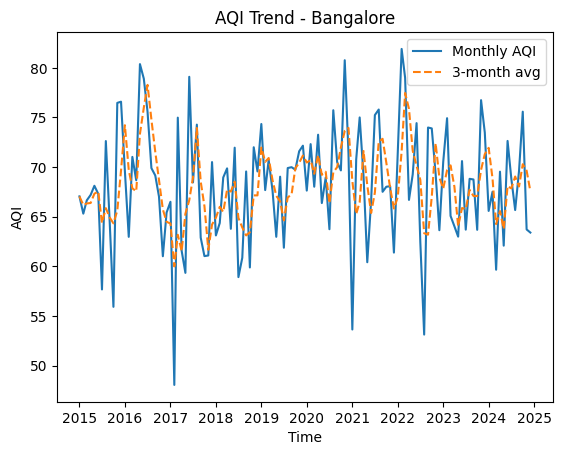

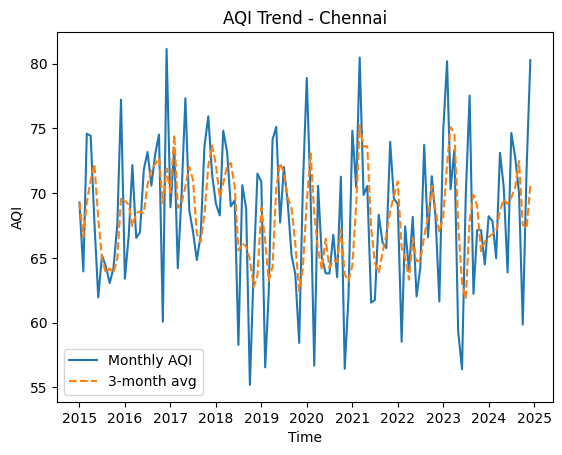

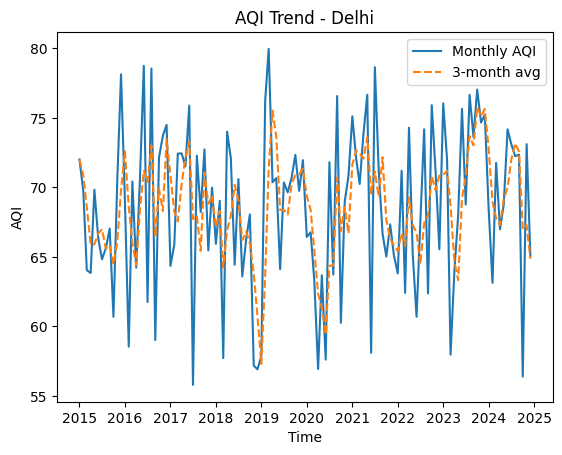

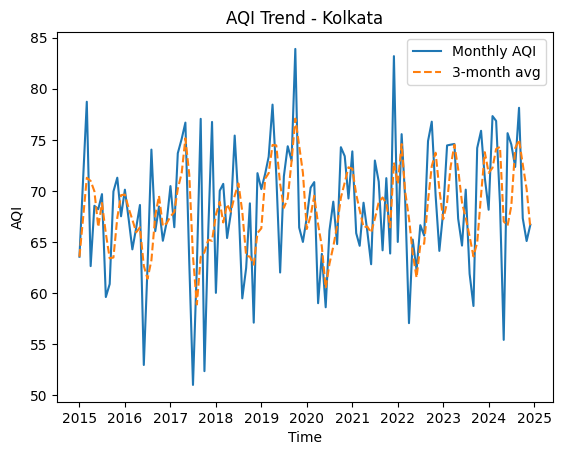

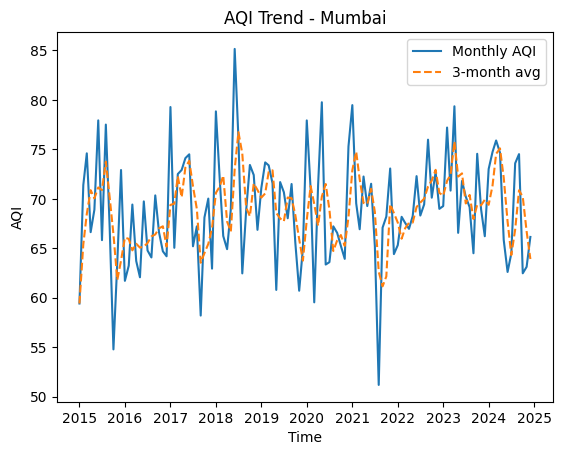

In [63]:
for city in monthly_df['City'].unique():
    city_df = monthly_df[monthly_df['City'] == city]

    plt.figure()
    plt.plot(city_df['MonthStart'], city_df['AQI'], label='Monthly AQI')
    plt.plot(city_df['MonthStart'], city_df['AQI_3month_avg'], linestyle='--', label='3-month avg')

    plt.title(f"AQI Trend - {city}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

In [64]:
import statsmodels.formula.api as smf

# Time index (trend)
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical
monthly_df['Month'] = monthly_df['Month'].astype('category')